# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [1]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: c:\Users\alvin\.pyenv\pyenv-win\versions\3.12.2\python.exe -m pip install --upgrade pip


---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
import os
from dotenv import load_dotenv
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# Load environment variables
load_dotenv()

def normalize_cwa_json(data):
    """Normalize CWA rainfall JSON to flat structure"""
    normalized = []
    for station in data['records']['Station']:
        # Extract coordinates
        coords = station['GeoInfo']['Coordinates'][0]
        lat = coords['StationLatitude']
        lon = coords['StationLongitude']
        
        # Extract rainfall data
        rainfall = station['RainfallElement']
        
        # Create flat record
        record = {
            'station_id': station['StationId'],
            'station_name': station['StationName'],
            'county': station['GeoInfo']['CountyName'],
            'town': station['GeoInfo']['TownName'],
            'latitude': lat,
            'longitude': lon,
            'obs_time': station['ObsTime']['DateTime'],
            'rain_10min': rainfall['Past10Min']['Precipitation'],
            'rain_1hr': rainfall['Past1hr']['Precipitation'],
            'rain_3hr': rainfall['Past3hr']['Precipitation'],
            'rain_6hr': rainfall['Past6hr']['Precipitation'],
            'rain_12hr': rainfall['Past12hr']['Precipitation'],
            'rain_24hr': rainfall['Past24hr']['Precipitation']
        }
        normalized.append(record)
    return normalized

def parse_rainfall_json(json_path):
    """Parse CWA rainfall JSON file into GeoDataFrame"""
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Normalize data
    normalized_data = normalize_cwa_json(data)
    
    # Create DataFrame
    df = pd.DataFrame(normalized_data)
    
    # Create GeoDataFrame
    geometry = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    
    return gdf

# Get data path from environment variables
data_path = os.getenv('SIMULATION_DATA', 'data/scenarios/fungwong_202511.json')
api_key = os.getenv('CWA_API_KEY')

# Load and process data
print(f"Loading data from: {data_path}")
if api_key:
    print(f"CWA API Key available: {api_key[:10]}...")
else:
    print("No CWA API Key found in environment")

gdf = parse_rainfall_json(data_path)

# Filter to 花蓮縣 and 宜蘭縣
study_rain = gdf[gdf['county'].isin(['花蓮縣', '宜蘭縣'])].copy()

# Remove stations with rain_1hr <= 0 (including -998)
study_rain = study_rain[study_rain['rain_1hr'] > 0]

# Convert to EPSG:3826
study_rain_3826 = study_rain.to_crs('EPSG:3826')

# Extract coordinate arrays for Kriging / ML
x = study_rain_3826.geometry.x.values  # Easting (meters)
y = study_rain_3826.geometry.y.values  # Northing (meters)
z = study_rain_3826['rain_1hr'].values

print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print(f"\nTop 5 stations:")
print(study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county', 'rain_1hr']].to_string(index=False))

Loading data from: data/scenarios/fungwong_202511.json
CWA API Key available: CWA-468F62...
Study area stations (rain > 0): 89
CRS: EPSG:3826

Top 5 stations:
station_name county  rain_1hr
          蘇澳    宜蘭縣     130.5
     國五S047K    宜蘭縣      80.5
          五結    宜蘭縣      71.0
          冬山    宜蘭縣      61.5
     國五S041K    宜蘭縣      46.0


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

Running naive Kriging on raw rainfall data...
Initial parameters:
  Sill: 400.9
  Range: 50.0 km
  Nugget: 40.1


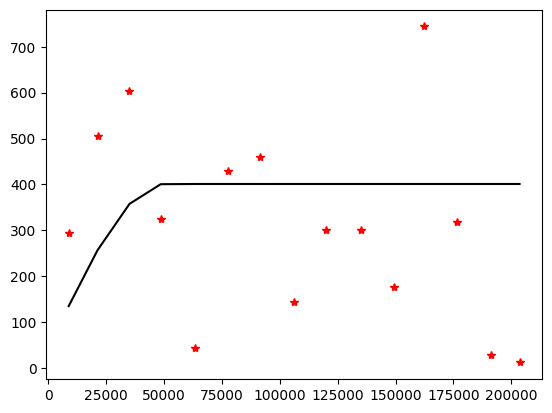


Optimized parameters:
Sill:   360.8
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [3]:
from pykrige.ok import OrdinaryKriging

# 🔴 First attempt: run Kriging on raw rainfall data
# 1. Create OrdinaryKriging with raw z values
#    Use variogram_model='spherical', verbose=False, enable_plotting=True, nlags=15
# 2. Provide initial parameters to help the optimizer:
#    sill = z.var(), range = 50000, nugget = z.var() * 0.1

initial_sill = float(z.var())
initial_range = 50000.0
initial_nugget = float(z.var() * 0.1)

print("Running naive Kriging on raw rainfall data...")
print(f"Initial parameters:")
print(f"  Sill: {initial_sill:.1f}")
print(f"  Range: {initial_range/1000:.1f} km")
print(f"  Nugget: {initial_nugget:.1f}")

OK_naive = OrdinaryKriging(x, y, z, variogram_model='spherical',
                            verbose=False, enable_plotting=True, nlags=15,
                            variogram_parameters={'sill': initial_sill,
                                                  'range': initial_range,
                                                  'nugget': initial_nugget})

params = OK_naive.variogram_model_parameters
print(f"\nOptimized parameters:")
print(f"Sill:   {params[0]:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")
print("\n⚠️ Look at the plot — do the dots follow the curve?")

## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

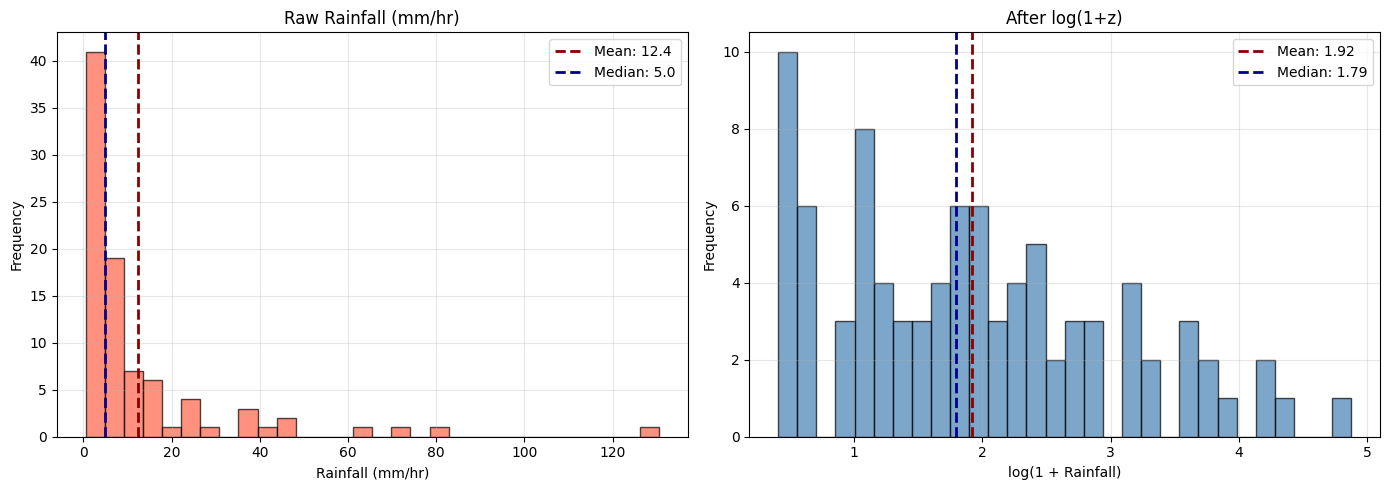

=== Data Distribution Analysis ===
Raw rainfall statistics:
  Mean: 12.37 mm/hr
  Median: 5.00 mm/hr
  Std: 20.02 mm/hr
  Min: 0.50 mm/hr
  Max: 130.50 mm/hr
  Skewness: 3.41

Log-transformed statistics:
  Mean: 1.92
  Median: 1.79
  Std: 1.09
  Min: 0.41
  Max: 4.88
  Skewness: 0.56

📊 Interpretation:
Left: most stations < 10 mm, but a few are 50-130 mm.
Those extreme values mess up the variogram.
Right: after log-transform, the values are more balanced.


In [4]:
# YOUR CODE HERE:
# 1. Plot a histogram of z (raw rainfall)
# 2. Plot a histogram of np.log1p(z) (log-transformed)
# 3. Compare: which one looks more "balanced"?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw rainfall histogram
axes[0].hist(z, bins=30, color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title('Raw Rainfall (mm/hr)')
axes[0].set_xlabel('Rainfall (mm/hr)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Add statistics for raw data
axes[0].axvline(z.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {z.mean():.1f}')
axes[0].axvline(np.median(z), color='darkblue', linestyle='--', linewidth=2, label=f'Median: {np.median(z):.1f}')
axes[0].legend()

# Log-transformed rainfall histogram
z_log = np.log1p(z)
axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('After log(1+z)')
axes[1].set_xlabel('log(1 + Rainfall)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

# Add statistics for log-transformed data
axes[1].axvline(z_log.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {z_log.mean():.2f}')
axes[1].axvline(np.median(z_log), color='darkblue', linestyle='--', linewidth=2, label=f'Median: {np.median(z_log):.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("=== Data Distribution Analysis ===")
print(f"Raw rainfall statistics:")
print(f"  Mean: {z.mean():.2f} mm/hr")
print(f"  Median: {np.median(z):.2f} mm/hr")
print(f"  Std: {z.std():.2f} mm/hr")
print(f"  Min: {z.min():.2f} mm/hr")
print(f"  Max: {z.max():.2f} mm/hr")
print(f"  Skewness: {pd.Series(z).skew():.2f}")

print(f"\nLog-transformed statistics:")
print(f"  Mean: {z_log.mean():.2f}")
print(f"  Median: {np.median(z_log):.2f}")
print(f"  Std: {z_log.std():.2f}")
print(f"  Min: {z_log.min():.2f}")
print(f"  Max: {z_log.max():.2f}")
print(f"  Skewness: {pd.Series(z_log).skew():.2f}")

print("\n📊 Interpretation:")
print("Left: most stations < 10 mm, but a few are 50-130 mm.")
print("Those extreme values mess up the variogram.")
print("Right: after log-transform, the values are more balanced.")

## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

Running Kriging on log-transformed rainfall data...
Initial parameters:
  Sill: 1.196
  Range: 50.0 km
  Nugget: 0.120


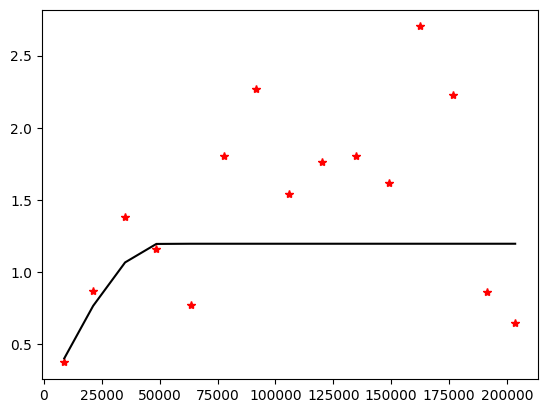


Optimized parameters:
Sill:   1.076
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve now.
📈 The variogram fit should be much better after log-transform!

📊 Comparison with naive attempt:
Data range improvement:
  Raw: 0.5 - 130.5 mm/hr (range: 130.0)
  Log: 0.41 - 4.88 (range: 4.47)
  Variance reduction: 99.7%


In [5]:
# 🟢 Second attempt: Kriging on log-transformed data
# 1. z_log = np.log1p(z)  (already computed above)
# 2. Create OrdinaryKriging with z_log (not z!)
# 3. Use initial parameters based on z_log.var()

# Use log-transformed data (already computed in Cell 2b)
z_log = np.log1p(z)

initial_sill = float(z_log.var())
initial_range = 50000.0
initial_nugget = float(z_log.var() * 0.1)

print("Running Kriging on log-transformed rainfall data...")
print(f"Initial parameters:")
print(f"  Sill: {initial_sill:.3f}")
print(f"  Range: {initial_range/1000:.1f} km")
print(f"  Nugget: {initial_nugget:.3f}")

OK = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                      verbose=False, enable_plotting=True, nlags=15,
                      variogram_parameters={'sill': initial_sill,
                                            'range': initial_range,
                                            'nugget': initial_nugget})

params = OK.variogram_model_parameters
print(f"\nOptimized parameters:")
print(f"Sill:   {params[0]:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")

print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")
print("📈 The variogram fit should be much better after log-transform!")

# Additional comparison metrics
print(f"\n📊 Comparison with naive attempt:")
print(f"Data range improvement:")
print(f"  Raw: {z.min():.1f} - {z.max():.1f} mm/hr (range: {z.max()-z.min():.1f})")
print(f"  Log: {z_log.min():.2f} - {z_log.max():.2f} (range: {z_log.max()-z_log.min():.2f})")
print(f"  Variance reduction: {(z.var() - z_log.var())/z.var()*100:.1f}%")

## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

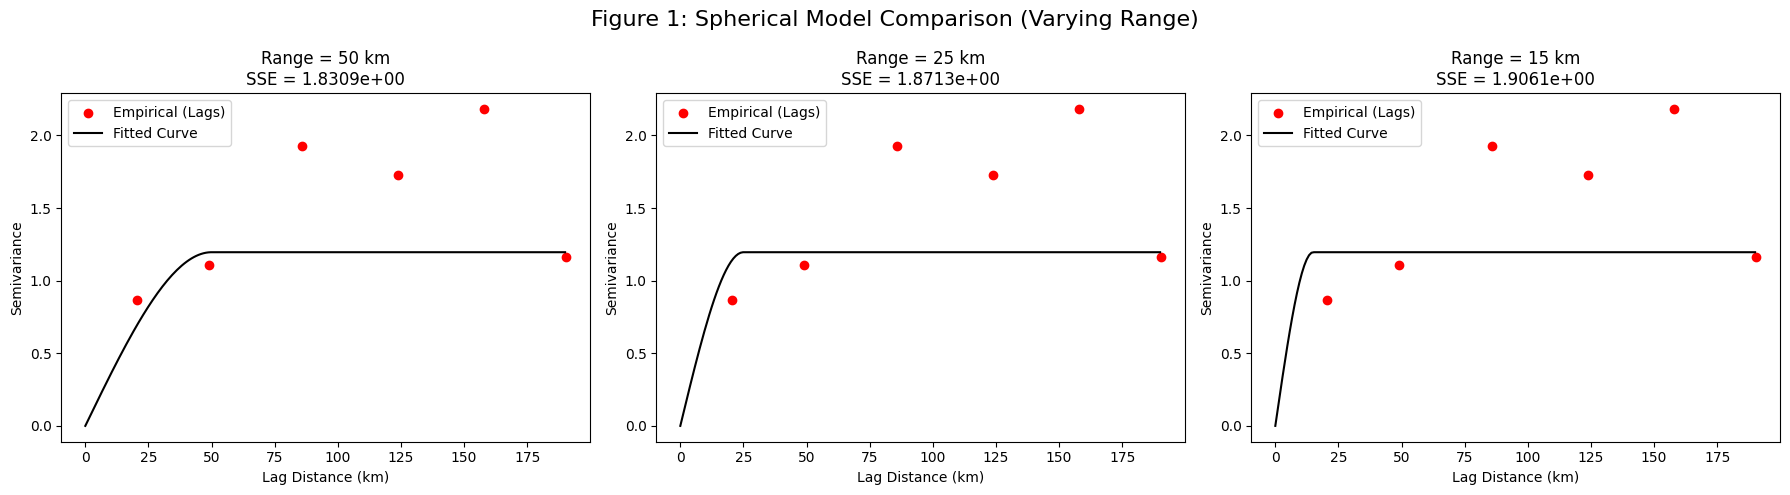

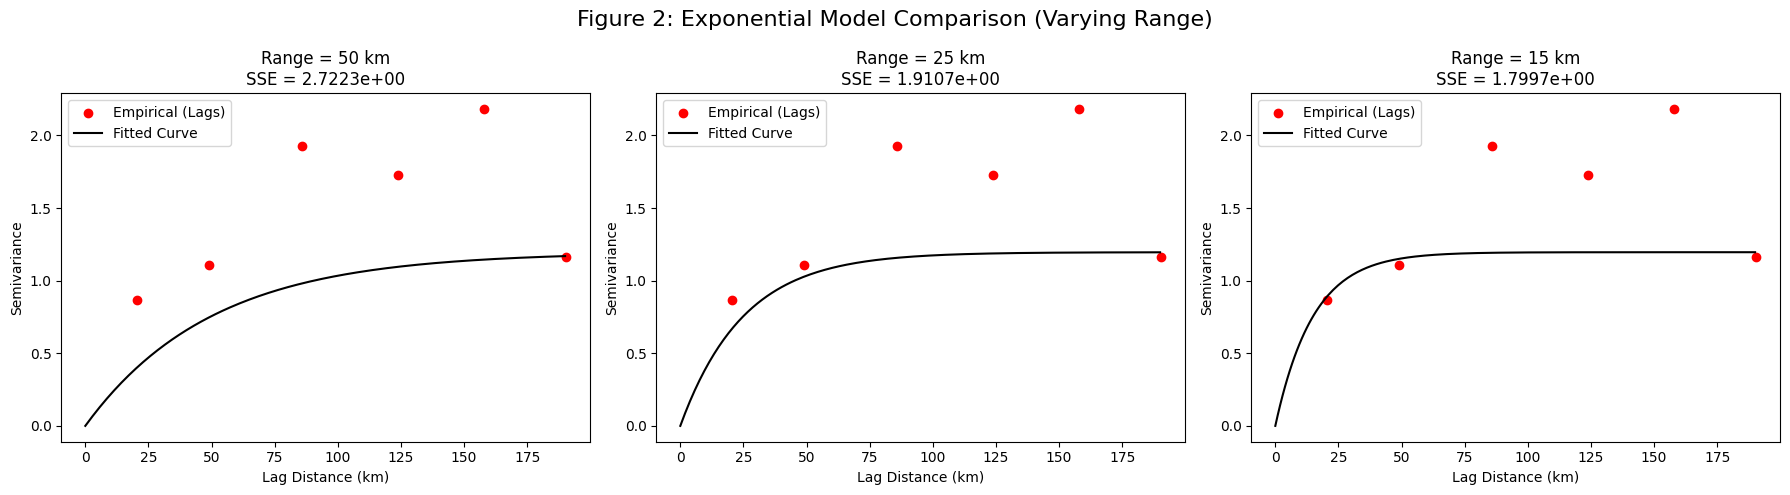


 VARIOGRAM FIT SUMMARY TABLE (SSE) 
            Spherical SSE  Exponential SSE
Range (km)                                
50               1.830909         2.722252
25               1.871302         1.910732
15               1.906104         1.799723



In [12]:
# 修復後的程式碼

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pykrige.ok import OrdinaryKriging

# ==========================================
# 0. 數據與全球參數定義
# ==========================================
# 請替換為你的實際數據 (x, y, z_log)
# x = ...
# y = ...
# z_log = ...

# 我們可以從經驗數據中估計 Sill 和 Nugget，並保持它們不變，以便隔離 Range 效果
global_sill = np.var(z_log) 
global_nugget = 0.0 # 強制 Nugget 為 0 

ranges_km = [50, 25, 15]

# 用於儲存 SSE 誤差，以便最後生成摘要表格
sse_spherical = []
sse_exponential = []

# ==========================================
# ─── Figure 1: Spherical (球狀模型) ───
# ==========================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Figure 1: Spherical Model Comparison (Varying Range)', fontsize=16)

# [修復] 用於繪製平滑且精細曲線的距離序列 (例如從 0 到 190 km)
# 這能保證曲線形狀不論 Range 多小都能正確呈現
lags_smooth = np.linspace(0, 190000, 200)

# 手動定義變異圖公式，以確保曲線繪製與 pykrige 自動擬合無關
# [sill, range, nugget] 對於 Spherical
def spherical_variogram(p, d):
    sill, range_, nugget = p
    d_ = np.where(d < range_, d / range_, 1.0)
    semi = nugget + (sill - nugget) * (1.5 * d_ - 0.5 * d_**3)
    return semi

for ax, rkm in zip(axes1, ranges_km):
    # 1. 初始化 普通克利金
    params = {'sill': global_sill, 'range': rkm * 1000, 'nugget': global_nugget}
    ok_sph = OrdinaryKriging(
        x, y, z_log,
        variogram_model='spherical',
        variogram_parameters=params
    )
    
    # 2. 獲取經驗數據 (紅點)
    empirical_semi = ok_sph.semivariance
    empirical_lags = ok_sph.lags
    
    # 3. [修復] 計算理論曲線 (黑線)
    # 我們不依賴 ok_sph 的 lags，而是使用我們定義的 lags_smooth
    # 參數順序對應球面模型公式：[sill, range, nugget]
    params_list = [global_sill, rkm * 1000, global_nugget]
    theoretical_semi_smooth = spherical_variogram(params_list, lags_smooth)
    
    # 用於計算誤差：我們需要計算在經驗 lag 距離處的理論半變異數
    theoretical_semi_empirical = spherical_variogram(params_list, ok_sph.lags)
    
    # 4. [修復] 計算 SSE 誤差
    sse = np.sum((empirical_semi - theoretical_semi_empirical)**2)
    sse_spherical.append(sse)
    
    # 5. 繪圖
    ax.scatter(empirical_lags / 1000, empirical_semi, c='red', label='Empirical (Lags)')
    ax.plot(lags_smooth / 1000, theoretical_semi_smooth, c='black', label=f'Fitted Curve')
    ax.set_title(f'Range = {rkm} km\nSSE = {sse:.4e}')
    ax.set_xlabel('Lag Distance (km)')
    ax.set_ylabel('Semivariance')
    ax.legend()

plt.tight_layout()
plt.show() # [修復] 將 plt.show() 移到循環之外，顯示 1x3 的子圖


# ==========================================
# ─── Figure 2: Exponential (指數模型) ───
# ==========================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Figure 2: Exponential Model Comparison (Varying Range)', fontsize=16)

# [sill, range, nugget] 對於 Exponential
def exponential_variogram(p, d):
    sill, range_, nugget = p
    semi = nugget + (sill - nugget) * (1 - np.exp(-d / range_))
    return semi

for ax, rkm in zip(axes2, ranges_km):
    # 1. 初始化 OK
    params = {'sill': global_sill, 'range': rkm * 1000, 'nugget': global_nugget}
    ok_exp = OrdinaryKriging(
        x, y, z_log,
        variogram_model='exponential',
        variogram_parameters=params
    )
    
    # 2. 獲取經驗數據 (紅點)
    empirical_semi = ok_exp.semivariance
    empirical_lags = ok_exp.lags
    
    # 3. [修復] 計算理論曲線 (黑線)
    params_list = [global_sill, rkm * 1000, global_nugget]
    theoretical_semi_smooth = exponential_variogram(params_list, lags_smooth)
    
    # 計算在經驗 lag 距離處的理論半變異數，以便計算 SSE
    theoretical_semi_empirical = exponential_variogram(params_list, ok_exp.lags)
    
    # 4. [修復] 計算 SSE 誤差
    sse = np.sum((empirical_semi - theoretical_semi_empirical)**2)
    sse_exponential.append(sse)
    
    # 5. 繪圖
    ax.scatter(empirical_lags / 1000, empirical_semi, c='red', label='Empirical (Lags)')
    ax.plot(lags_smooth / 1000, theoretical_semi_smooth, c='black', label='Fitted Curve')
    ax.set_title(f'Range = {rkm} km\nSSE = {sse:.4e}')
    ax.set_xlabel('Lag Distance (km)')
    ax.set_ylabel('Semivariance')
    ax.legend()

plt.tight_layout()
plt.show() # [修復] 將 plt.show() 移到循環之外

# ==========================================
# ─── 摘要表格 (Summary Table) ───
# ==========================================
summary_df = pd.DataFrame({
    'Range (km)': ranges_km,
    'Spherical SSE': sse_spherical,
    'Exponential SSE': sse_exponential
}).set_index('Range (km)')

print("\n" + "="*50)
print(" VARIOGRAM FIT SUMMARY TABLE (SSE) ")
print("="*50)
print(summary_df)
print("="*50 + "\n")

## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [13]:
import time

# YOUR CODE HERE:
# 1. Calculate grid extent from x, y arrays (with 5km buffer)
# 2. Create grid_x and grid_y using np.arange with 1000m step
# 3. Execute Kriging in log-space: z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# 4. Back-transform: z_kriging = np.expm1(z_kriging_log)

buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

# Calculate grid extent with buffer
x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m

# Create regular grid
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid Information:")
print(f"  X range: {x_min:.0f} - {x_max:.0f} m ({(x_max-x_min)/1000:.1f} km)")
print(f"  Y range: {y_min:.0f} - {y_max:.0f} m ({(y_max-y_min)/1000:.1f} km)")
print(f"  Resolution: {resolution} m")
print(f"  Grid size: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points")

# Execute Kriging
print(f"\nExecuting Ordinary Kriging...")
t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
kriging_time = time.time() - t0

print(f"✓ Kriging (log-space) completed in {kriging_time:.1f} seconds")
print(f"  Log-space prediction range: {np.nanmin(z_kriging_log):.3f} - {np.nanmax(z_kriging_log):.3f}")
print(f"  Log-space variance range: {np.nanmin(ss_kriging_log):.3f} - {np.nanmax(ss_kriging_log):.3f}")

# Back-transform to real rainfall (mm/hr)
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0  # Ensure no negative rainfall
ss_kriging = ss_kriging_log  # Keep log-space variance for Sigma Map

print(f"\nBack-transformed results:")
print(f"  Rainfall range: {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f} mm/hr")
print(f"  Variance range: {np.nanmin(ss_kriging):.3f} - {np.nanmax(ss_kriging):.3f}")

# Additional statistics
print(f"\nGrid Statistics:")
print(f"  Total grid points: {len(grid_x)*len(grid_y):,}")
print(f"  Valid predictions: {np.sum(~np.isnan(z_kriging)):,}")
print(f"  Coverage ratio: {np.sum(~np.isnan(z_kriging))/(len(grid_x)*len(grid_y))*100:.1f}%")

print(f"\n🎯 Key Points:")
print(f"  • Grid units are in meters (same as EPSG:3826)")
print(f"  • {buffer_m/1000:.0f}km buffer ensures edge coverage")
print(f"  • Back-transform with np.expm1() converts from log-space to mm/hr")
print(f"  • Negative values set to 0 (physically meaningful)")

Grid Information:
  X range: 264261 - 351034 m (86.8 km)
  Y range: 2558311 - 2768948 m (210.6 km)
  Resolution: 1000 m
  Grid size: 87×211 = 18,357 points

Executing Ordinary Kriging...
✓ Kriging (log-space) completed in 0.1 seconds
  Log-space prediction range: 0.420 - 4.279
  Log-space variance range: 0.172 - 1.320

Back-transformed results:
  Rainfall range: 0.5 - 71.2 mm/hr
  Variance range: 0.172 - 1.320

Grid Statistics:
  Total grid points: 18,357
  Valid predictions: 18,357
  Coverage ratio: 100.0%

🎯 Key Points:
  • Grid units are in meters (same as EPSG:3826)
  • 5km buffer ensures edge coverage
  • Back-transform with np.expm1() converts from log-space to mm/hr
  • Negative values set to 0 (physically meaningful)


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

In [15]:
from sklearn.ensemble import RandomForestRegressor

# YOUR CODE HERE:
# 1. Prepare features: X_train = np.column_stack([x, y])
# 2. Train RandomForestRegressor
# 3. Create meshgrid from grid_x, grid_y
# 4. Predict on the grid

# Prepare training data
X_train = np.column_stack([x, y])  # Features: [easting, northing]
y_train = z  # Target: rainfall_1hr

print(f"Training Data:")
print(f"  Features shape: {X_train.shape}")
print(f"  Target shape: {y_train.shape}")
print(f"  Feature range: X=[{x.min():.0f}-{x.max():.0f}], Y=[{y.min():.0f}-{y.max():.0f}]")

# Train Random Forest model
print(f"\nTraining Random Forest...")
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

t0 = time.time()
rf.fit(X_train, y_train)
training_time = time.time() - t0

# Calculate training R²
train_r2 = rf.score(X_train, y_train)

print(f"✓ Random Forest training completed in {training_time:.2f} seconds")
print(f"  Training R²: {train_r2:.3f}")
print(f"  Number of trees: {rf.n_estimators}")

# Get tree depth information (safely)
if hasattr(rf, 'estimators_') and len(rf.estimators_) > 0:
    depths = [tree.get_depth() for tree in rf.estimators_]
    print(f"  Tree depth range: {min(depths):.0f} - {max(depths):.0f}")
    print(f"  Average tree depth: {np.mean(depths):.1f}")

# Create prediction grid
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

print(f"\nPrediction Grid:")
print(f"  Grid shape: {grid_xx.shape}")
print(f"  Prediction points: {X_grid.shape[0]:,}")

# Make predictions
print(f"\nMaking predictions...")
t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
prediction_time = time.time() - t0

print(f"✓ Random Forest prediction completed in {prediction_time:.2f} seconds")
print(f"  Prediction range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")
print(f"  Mean prediction: {z_rf.mean():.1f} mm/hr")

# Compare with training data
print(f"\nComparison with Training Data:")
print(f"  Training data range: {y_train.min():.1f} - {y_train.max():.1f} mm/hr")
print(f"  Training data mean: {y_train.mean():.1f} mm/hr")
print(f"  RF vs Training mean difference: {abs(z_rf.mean() - y_train.mean()):.1f} mm/hr")

# Additional statistics
print(f"\nRandom Forest Characteristics:")
print(f"  • Uses spatial coordinates as features (easting, northing)")
print(f"  • Learns non-linear spatial patterns")
print(f"  • No built-in uncertainty quantification")
print(f"  • Fast prediction on large grids")
print(f"  • May show 'blocky' artifacts in smooth regions")

Training Data:
  Features shape: (89, 2)
  Target shape: (89,)
  Feature range: X=[269261-346034], Y=[2563311-2763948]

Training Random Forest...
✓ Random Forest training completed in 0.23 seconds
  Training R²: 0.775
  Number of trees: 200
  Tree depth range: 5 - 9
  Average tree depth: 6.1

Prediction Grid:
  Grid shape: (211, 87)
  Prediction points: 18,357

Making predictions...
✓ Random Forest prediction completed in 0.07 seconds
  Prediction range: 0.6 - 62.6 mm/hr
  Mean prediction: 8.4 mm/hr

Comparison with Training Data:
  Training data range: 0.5 - 130.5 mm/hr
  Training data mean: 12.4 mm/hr
  RF vs Training mean difference: 3.9 mm/hr

Random Forest Characteristics:
  • Uses spatial coordinates as features (easting, northing)
  • Learns non-linear spatial patterns
  • No built-in uncertainty quantification
  • Fast prediction on large grids
  • May show 'blocky' artifacts in smooth regions


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [16]:
# YOUR CODE HERE:
# 1. Print rf.feature_importances_
# 2. Interpret: which dimension matters more for typhoon rainfall?

importances = rf.feature_importances_
feature_names = ['Easting (X)', 'Northing (Y)']

print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 40)
print(f"Feature Importances:")
for i, (name, importance) in enumerate(zip(feature_names, importances)):
    print(f"  {name:15s}: {importance:.3f} ({importance*100:.1f}%)")

print(f"\nTotal: {sum(importances):.3f}")

# Determine which feature is more important
dominant_feature = feature_names[np.argmax(importances)]
dominant_importance = max(importances)
dominant_percentage = dominant_importance * 100

print(f"\nDOMINANT FEATURE:")
print(f"  {dominant_feature} is most important ({dominant_percentage:.1f}% of importance)")

# Physical interpretation
print(f"\nPHYSICAL INTERPRETATION:")
if importances[0] > importances[1]:  # Easting more important
    print(f"  • East-West dimension (Easting) dominates rainfall pattern")
    print(f"  • Suggests stronger east-west rainfall gradient")
    print(f"  • May reflect typhoon track or orographic effects")
else:  # Northing more important
    print(f"  • North-South dimension (Northing) dominates rainfall pattern") 
    print(f"  • Suggests stronger north-south rainfall gradient")
    print(f"  • May reflect latitude effects or mountain range influence")

# Compare with data characteristics
print(f"\nDATA CONTEXT:")
print(f"  • Study area: 花蓮縣 + 宜蘭縣")
print(f"  • Coordinate range: X=[{x.min():.0f}-{x.max():.0f}], Y=[{y.min():.0f}-{y.max():.0f}]")
print(f"  • X-span: {(x.max()-x.min())/1000:.1f} km")
print(f"  • Y-span: {(y.max()-y.min())/1000:.1f} km")

# Typhoon-specific interpretation
print(f"\nTYPHOON FUNG-WONG CONTEXT:")
print(f"  • Typhoons often show asymmetric rainfall patterns")
print(f"  • East coast (花蓮) vs northeast coast (宜蘭) differences")
print(f"  • Central mountain range creates strong orographic effects")

print(f"\n💡 KEY INSIGHT:")
print(f"  The model relies mostly on {'easting' if importances[0] > importances[1] else 'northing'}.")
print(f"  This suggests the dominant spatial gradient in typhoon rainfall for this region.")

RANDOM FOREST FEATURE IMPORTANCE
Feature Importances:
  Easting (X)    : 0.485 (48.5%)
  Northing (Y)   : 0.515 (51.5%)

Total: 1.000

DOMINANT FEATURE:
  Northing (Y) is most important (51.5% of importance)

PHYSICAL INTERPRETATION:
  • North-South dimension (Northing) dominates rainfall pattern
  • Suggests stronger north-south rainfall gradient
  • May reflect latitude effects or mountain range influence

DATA CONTEXT:
  • Study area: 花蓮縣 + 宜蘭縣
  • Coordinate range: X=[269261-346034], Y=[2563311-2763948]
  • X-span: 76.8 km
  • Y-span: 200.6 km

TYPHOON FUNG-WONG CONTEXT:
  • Typhoons often show asymmetric rainfall patterns
  • East coast (花蓮) vs northeast coast (宜蘭) differences
  • Central mountain range creates strong orographic effects

💡 KEY INSIGHT:
  The model relies mostly on northing.
  This suggests the dominant spatial gradient in typhoon rainfall for this region.


---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [18]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# Nearest Neighbor
nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
z_nn = nn_interp(grid_xx, grid_yy)

# IDW (Inverse Distance Weighting, power=2)
# ⚠ 注意: scipy.interpolate.Rbf(function='inverse') 不是真正的 IDW
# 因為會出現負值與偏移，這裡使用手動實作的標準 IDW
pts = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
dists = cdist(grid_pts, pts)
dists[dists < 1] = 1     # 避免除以零
power = 2
weights = 1.0 / (dists ** power)
z_idw = (weights @ z / weights.sum(axis=1)).reshape(grid_xx.shape)

print("✓ Nearest Neighbor + IDW computed")
print(f"  NN range: {z_nn.min():.1f} – {z_nn.max():.1f} mm/hr")
print(f"  IDW range: {z_idw.min():.1f} – {z_idw.max():.1f} mm/hr")

✓ Nearest Neighbor + IDW computed
  NN range: 0.5 – 130.5 mm/hr
  IDW range: 0.5 – 123.0 mm/hr


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

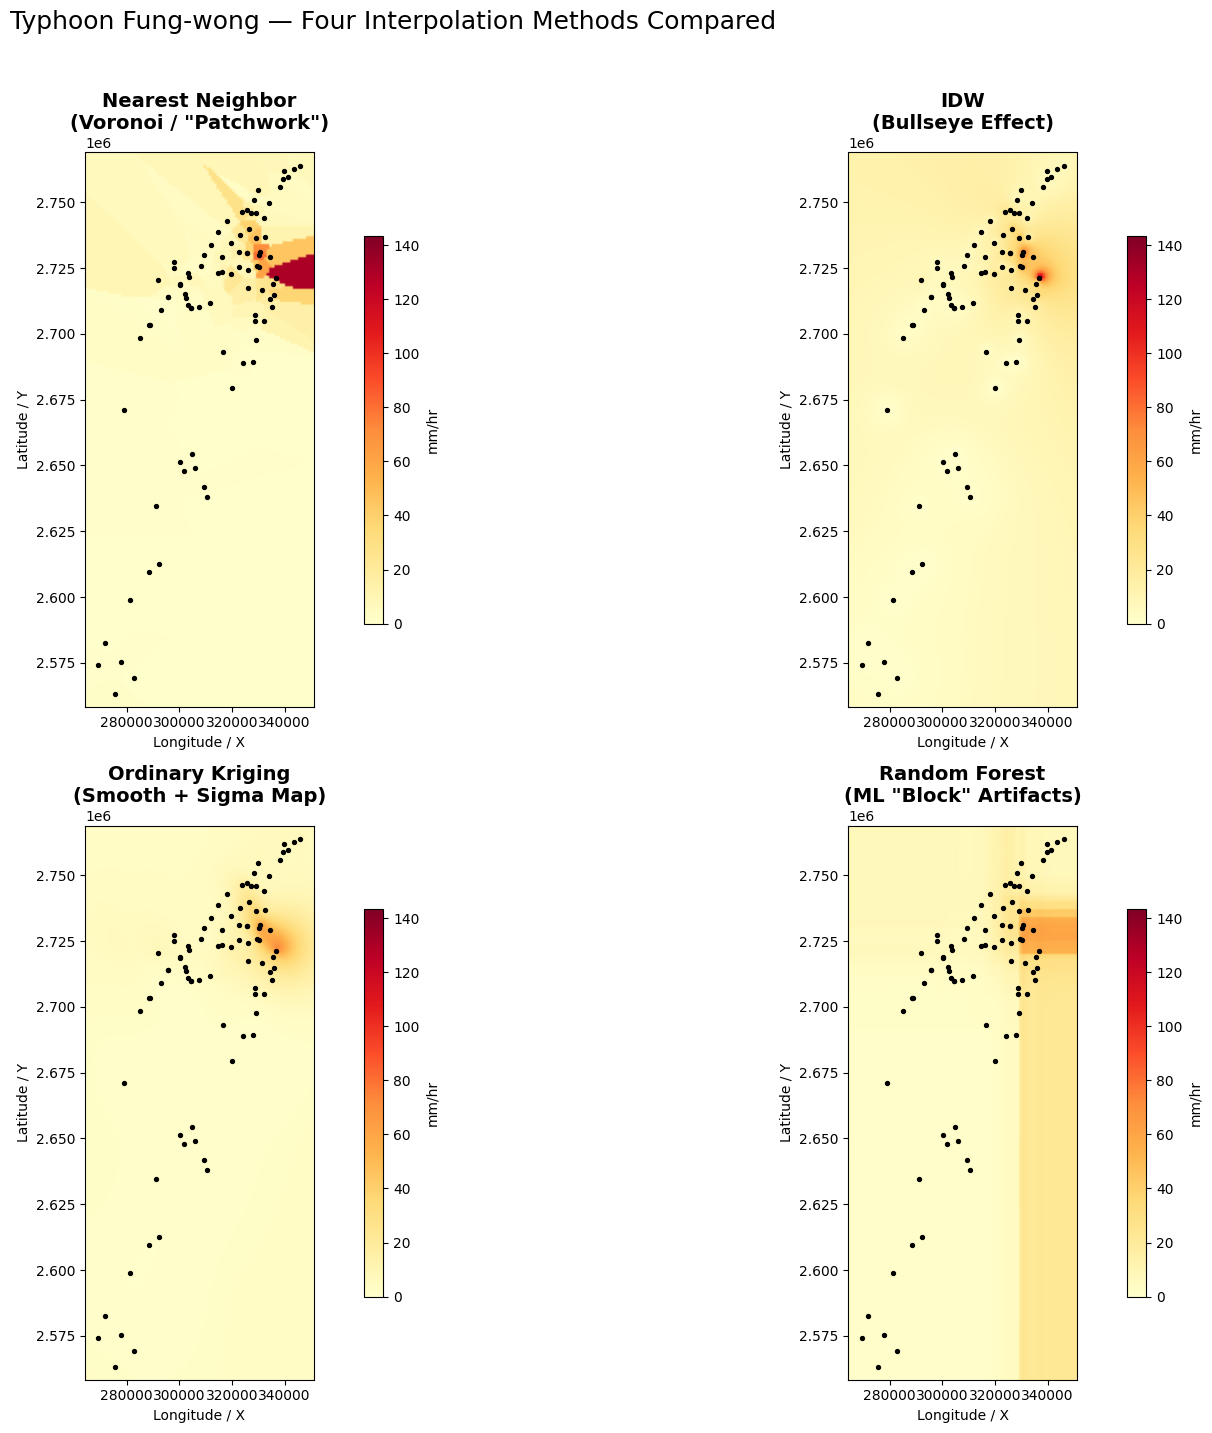

In [19]:
import matplotlib.pyplot as plt

# Ensure x_min, x_max, y_min, y_max, x, y, and z are defined from your earlier cells.
# Also ensure z_nn, z_idw, z_kriging, and z_rf are loaded in your environment.

# 1. Set a global maximum for the color scale (10% higher than max observation)
vmax = max(z) * 1.1

# 2. Create the 2x2 figure canvas
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 3. Define the configurations for the loop
methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)', z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf),
]

# 4. Loop through the axes and plot each method
for ax, (title, data) in zip(axes.flatten(), methods):
    # Plot the grid data
    im = ax.imshow(
        data, 
        extent=[x_min, x_max, y_min, y_max],
        origin='lower', 
        cmap='YlOrRd', 
        vmin=0, 
        vmax=vmax
    )
    
    # Overlay the original weather station points
    ax.scatter(x, y, c='black', s=8, zorder=5, label='Stations')
    
    # Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude / X')
    ax.set_ylabel('Latitude / Y')
    
    # Add a colorbar specific to each subplot
    plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

# 5. Final touches, save, and display
plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=18, y=1.02)
plt.tight_layout()

# Save high-resolution PNG before showing
plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

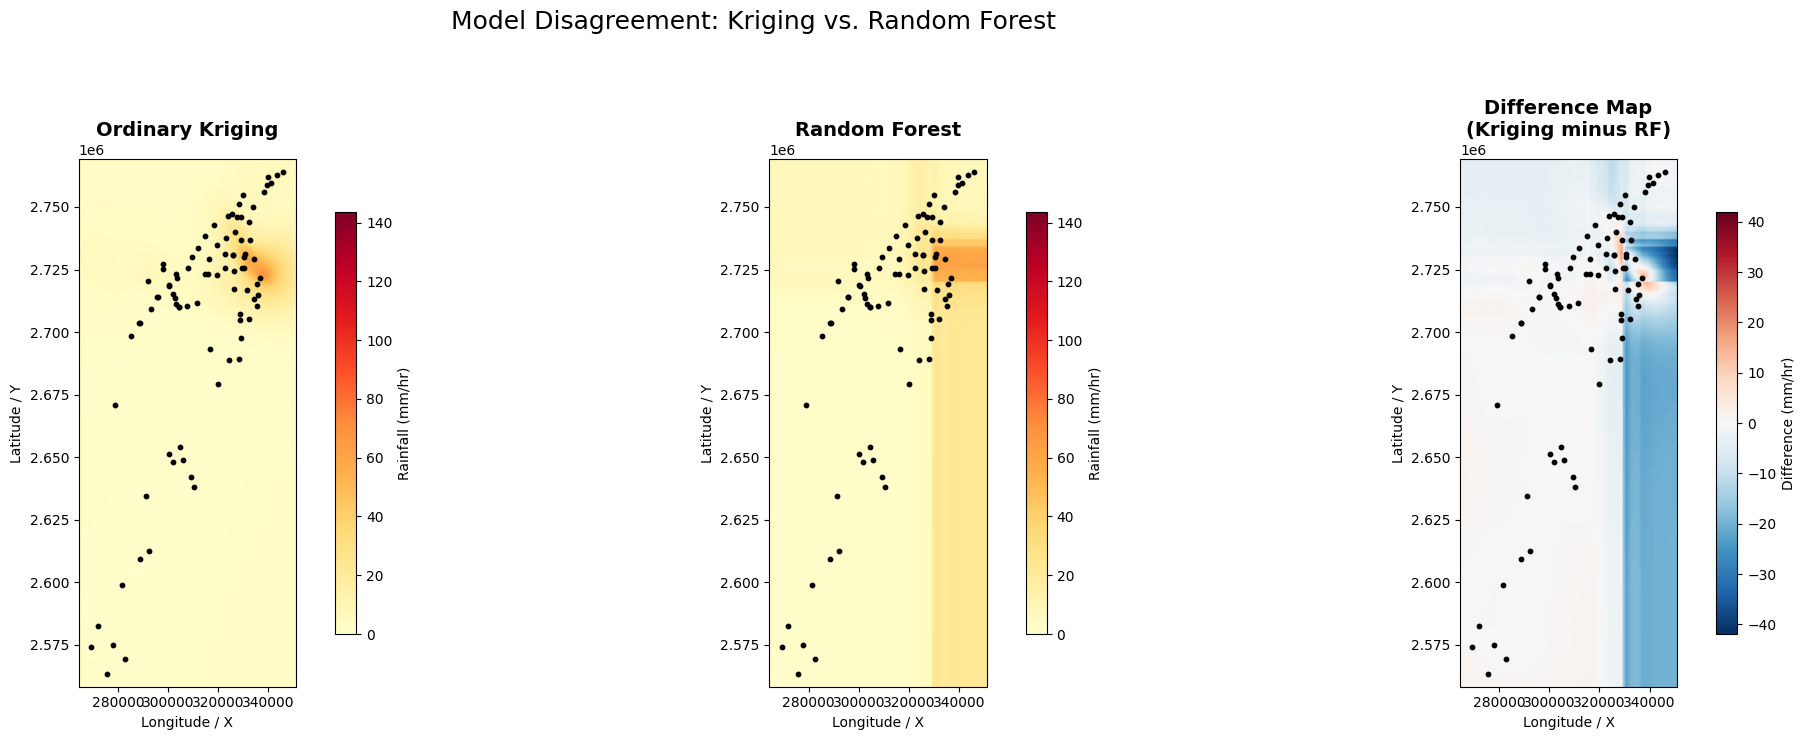

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure x_min, x_max, y_min, y_max, x, y, z, z_kriging, and z_rf are in your environment

# 1. Calculate the difference (Kriging - RF)
diff = z_kriging - z_rf

# 2. Set color limits
# For rainfall, keep the same scale as Cell 7 for fair comparison
vmax_rain = max(z) * 1.1 
# For the difference map, find the maximum absolute difference to make the colorbar perfectly symmetric around 0
vmax_diff = np.max(np.abs(diff))

# 3. Create the 1x3 figure
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Panel 1: Kriging ---
im1 = axes[0].imshow(
    z_kriging, extent=[x_min, x_max, y_min, y_max], 
    origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax_rain
)
axes[0].scatter(x, y, c='black', s=10, label='Stations', zorder=5)
axes[0].set_title('Ordinary Kriging', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='Rainfall (mm/hr)')

# --- Panel 2: Random Forest ---
im2 = axes[1].imshow(
    z_rf, extent=[x_min, x_max, y_min, y_max], 
    origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax_rain
)
axes[1].scatter(x, y, c='black', s=10, zorder=5)
axes[1].set_title('Random Forest', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Rainfall (mm/hr)')

# --- Panel 3: Difference Map ---
# Note the symmetric vmin and vmax using vmax_diff
im3 = axes[2].imshow(
    diff, extent=[x_min, x_max, y_min, y_max], 
    origin='lower', cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff
)
axes[2].scatter(x, y, c='black', s=10, zorder=5)
axes[2].set_title('Difference Map\n(Kriging minus RF)', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[2], shrink=0.8, label='Difference (mm/hr)')

# 4. Formatting
for ax in axes:
    ax.set_xlabel('Longitude / X')
    ax.set_ylabel('Latitude / Y')

plt.suptitle('Model Disagreement: Kriging vs. Random Forest', fontsize=18, y=1.05)
plt.tight_layout()

# 5. Save and show
plt.savefig('kriging_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Your Lab 1 reflection here:**

1. Most realistic: 我覺得是Ordinary Kriging，因為雨量看起來隨著空間距離平滑地遞減或遞增，不會有不自然的幾何形狀或極端的極值，看起來比較近似實際發生的情況。

2. Disagreement areas: 兩者差異最大的地方在蘇澳跟蘇澳外海附近，因為是極端降雨最高的地區。而且還有一個明顯的地方是蘇澳外海以南那一大部分的條狀區域。因為RF缺乏空間連續性跟資料外推的能力，所以會在這些地方產生不連續的結果。

3. Artifacts: Nearest Neighbor (NN) 產生許多生硬、像是拼圖一樣的區塊，區塊邊界的雨量只要跨過去便會發生跳躍性的斷層。而Random Forest (RF) 一樣也有區塊狀的問題，只是比較像是條狀，可能因為ML在決策的時候直接以經緯度切割，會形成生硬的邊界，兩者比較沒法貼近真實發生的情況。

4. Commander's choice: 我會選擇Ordinary Kriging，因為它能產生最平滑、符合空間連續性假設的結果，而且沒有明顯的Artifacts，比較貼近真實的降雨空間分布模式。

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

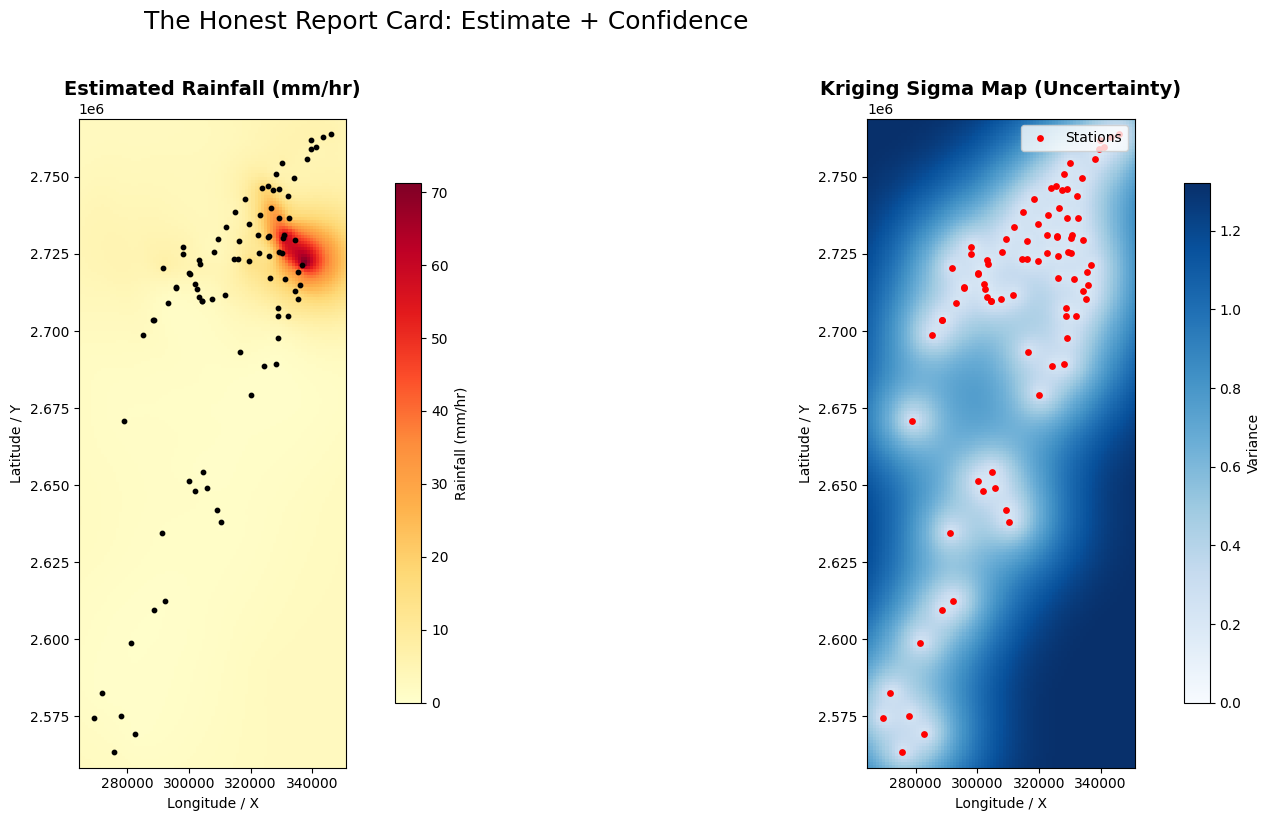

Variance range: 0.2 - 1.3


In [22]:
# YOUR CODE HERE:
# Create a 2-panel figure:
# Left: z_kriging with YlOrRd colormap (rainfall estimate)
# Right: ss_kriging with Blues colormap (variance/uncertainty)
# Add station locations on both panels (red dots on variance map)
# Save as 'sigma_map.png'

# fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# # Rainfall estimate
# im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='YlOrRd', vmin=0)
# axes[0].scatter(x, y, c='black', s=10, zorder=5)import matplotlib.pyplot as plt
import numpy as np

# 確保 x_min, x_max, y_min, y_max, x, y, z_kriging, ss_kriging 皆已存在環境中

# 1. 建立 1x2 的圖表畫布
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ==========================================
# 左圖：降雨量估計 (Rainfall Estimate)
# ==========================================
im1 = axes[0].imshow(
    z_kriging, 
    extent=[x_min, x_max, y_min, y_max],
    origin='lower', 
    cmap='YlOrRd', 
    vmin=0
)
axes[0].scatter(x, y, c='black', s=10, zorder=5, label='Stations')
axes[0].set_title('Estimated Rainfall (mm/hr)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude / X')
axes[0].set_ylabel('Latitude / Y')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='Rainfall (mm/hr)')

# ==========================================
# 右圖：Kriging 變異數/不確定性 (Sigma Map)
# ==========================================
im2 = axes[1].imshow(
    ss_kriging, 
    extent=[x_min, x_max, y_min, y_max],
    origin='lower', 
    cmap='Blues', 
    vmin=0
)
# 這裡將測站標示為紅色，在藍色背景上會非常醒目
axes[1].scatter(x, y, c='red', s=15, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude / X')
axes[1].set_ylabel('Latitude / Y')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

# ==========================================
# 整體排版與輸出
# ==========================================
plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=18, y=1.02)
plt.tight_layout()

# 儲存高解析度圖片並顯示
plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
plt.show()

# 印出變異數的範圍，供後續分析參考
print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}")
# axes[0].set_title('Estimated Rainfall (mm/hr)')
# plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# # Kriging Variance (Sigma Map)
# im2 = axes[1].imshow(ss_kriging, extent=[x_min, x_max, y_min, y_max],
#                       origin='lower', cmap='Blues', vmin=0)
# axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
# axes[1].set_title('Kriging Sigma Map (Uncertainty)')
# axes[1].legend(loc='upper right')
# plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

# plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
# plt.tight_layout()
# plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
# plt.show()

# print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}") 

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

Station with max rainfall (Suao): 130.5 mm/hr


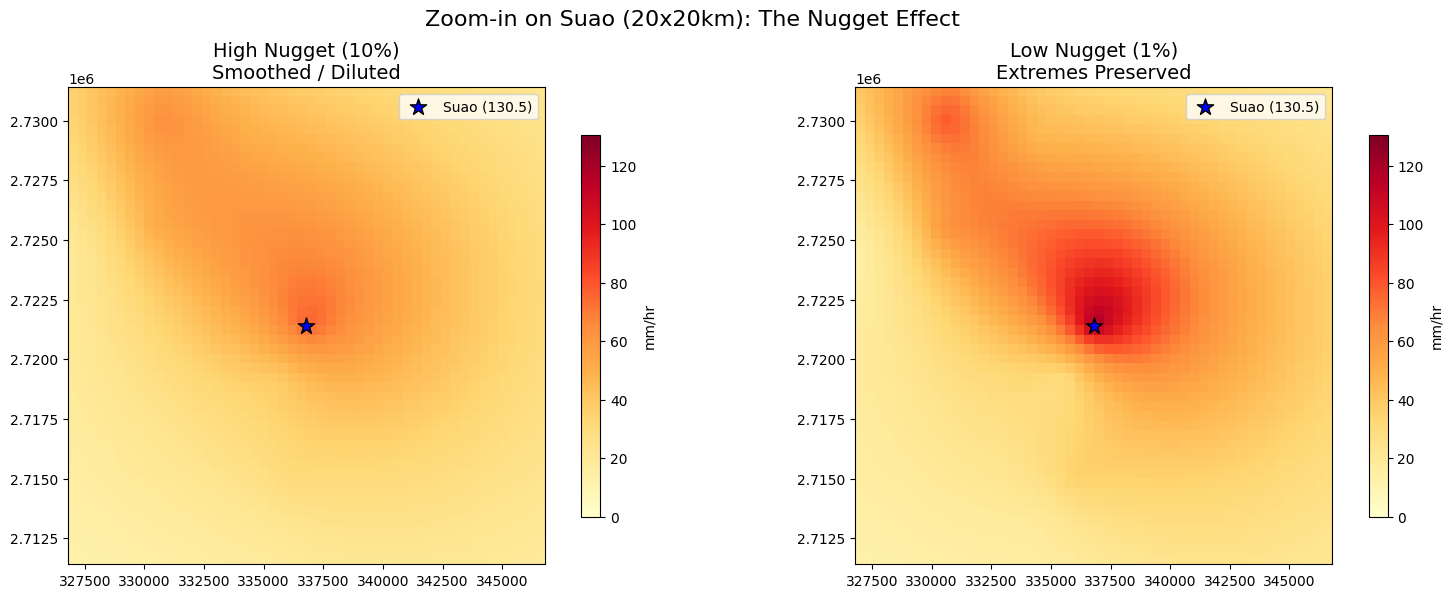


--- Point Prediction Comparison ---
Actual Suao Observation: 130.5 mm/hr

Distance from Suao High Nugget (10%) Low Nugget (1%)
               0 m       131.5 mm/hr     131.5 mm/hr
             500 m        71.9 mm/hr     108.3 mm/hr
            1000 m        68.3 mm/hr      99.8 mm/hr
            2000 m        62.0 mm/hr      86.7 mm/hr


In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pykrige.ok import OrdinaryKriging

# 1. 找出降雨量最大的測站 (蘇澳)
suao_idx = np.argmax(z)
suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
print(f"Station with max rainfall (Suao): {suao_z:.1f} mm/hr")

# 準備參數
sill_val = float(np.var(z_log))
range_val = 50000.0  # 假設影響範圍為 50km

# 2. 建立兩個 OrdinaryKriging 模型 (10% vs 1% Nugget)
# Model A: 高 Nugget (10% of Sill) - 認為測量有較大誤差/雜訊
ok_high_nugget = OrdinaryKriging(
    x, y, z_log, 
    variogram_model='spherical',
    variogram_parameters={'sill': sill_val, 'range': range_val, 'nugget': sill_val * 0.10}
)

# Model B: 低 Nugget (1% of Sill) - 高度信任測量值
ok_low_nugget = OrdinaryKriging(
    x, y, z_log, 
    variogram_model='spherical',
    variogram_parameters={'sill': sill_val, 'range': range_val, 'nugget': sill_val * 0.01}
)

# 3. 建立局部網格 (20km box, 以蘇澳為中心)
# 半徑 10km = 10000m
grid_x_local = np.linspace(suao_x - 10000, suao_x + 10000, 50)
grid_y_local = np.linspace(suao_y - 10000, suao_y + 10000, 50)

# 執行預測並轉換回原始尺度 (假設之前是使用 np.log 或 np.log1p)
# 如果你當初是用 z_log = np.log(z + 0.1)，這裡記得用 np.exp(pred) - 0.1
pred_log_high, _ = ok_high_nugget.execute('grid', grid_x_local, grid_y_local)
pred_log_low, _ = ok_low_nugget.execute('grid', grid_x_local, grid_y_local)

pred_high = np.exp(pred_log_high) # 根據你的 log 轉換方式調整
pred_low = np.exp(pred_log_low)

# 4. 繪製並排比較圖
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
vmax_local = max(np.max(pred_high), np.max(pred_low), suao_z)

# 高 Nugget 圖
im1 = axes[0].imshow(
    pred_high, extent=[grid_x_local[0], grid_x_local[-1], grid_y_local[0], grid_y_local[-1]],
    origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax_local
)
axes[0].scatter(suao_x, suao_y, c='blue', marker='*', s=150, edgecolors='black', label=f'Suao ({suao_z:.1f})')
axes[0].set_title('High Nugget (10%)\nSmoothed / Diluted', fontsize=14)
axes[0].legend()
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# 低 Nugget 圖
im2 = axes[1].imshow(
    pred_low, extent=[grid_x_local[0], grid_x_local[-1], grid_y_local[0], grid_y_local[-1]],
    origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax_local
)
axes[1].scatter(suao_x, suao_y, c='blue', marker='*', s=150, edgecolors='black', label=f'Suao ({suao_z:.1f})')
axes[1].set_title('Low Nugget (1%)\nExtremes Preserved', fontsize=14)
axes[1].legend()
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

plt.suptitle('Zoom-in on Suao (20x20km): The Nugget Effect', fontsize=16)
plt.tight_layout()
plt.show()

# 5. 在特定距離進行點預測 (0m, 500m, 1000m, 2000m)
offsets = [0, 500, 1000, 2000]
high_nugget_vals = []
low_nugget_vals = []

for d in offsets:
    # 為了簡單起見，我們沿著 X 軸向東偏移 d 距離來預測
    val_log_h, _ = ok_high_nugget.execute('points', np.array([suao_x + d]), np.array([suao_y]))
    val_log_l, _ = ok_low_nugget.execute('points', np.array([suao_x + d]), np.array([suao_y]))
    
    high_nugget_vals.append(np.exp(val_log_h[0]))
    low_nugget_vals.append(np.exp(val_log_l[0]))

# 6. 印出比較表格
df_offsets = pd.DataFrame({
    'Distance from Suao': [f"{d} m" for d in offsets],
    'High Nugget (10%)': [f"{v:.1f} mm/hr" for v in high_nugget_vals],
    'Low Nugget (1%)': [f"{v:.1f} mm/hr" for v in low_nugget_vals]
})

print("\n--- Point Prediction Comparison ---")
print(f"Actual Suao Observation: {suao_z:.1f} mm/hr\n")
print(df_offsets.to_string(index=False))

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [25]:
import rasterio
from rasterio.transform import from_bounds
import numpy as np

# 確保 x_min, y_min, x_max, y_max 以及你要輸出的陣列 (z_kriging, ss_kriging, z_rf) 都已定義
# 注意：你的陣列維度應該是 (height, width)

# 1. 建立 Rasterio 的 Transform (定義影像像素與真實世界座標的映射關係)
# width 必須對應陣列的欄數 (X軸)，height 對應列數 (Y軸)
transform = from_bounds(
    x_min, y_min, x_max, y_max,
    width=z_kriging.shape[1], 
    height=z_kriging.shape[0]
)

# 2. 建立儲存 GeoTIFF 的輔助函式
def save_geotiff(data, filename, crs='EPSG:3826'):
    """
    將 2D Numpy 陣列儲存為 GeoTIFF。
    預設 CRS 為 EPSG:3826 (TWD97 / TM2 zone 121，適合台灣本島)。
    """
    # ⚠️ 關鍵步驟：上下翻轉陣列
    data_flipped = np.flipud(data).astype(np.float32)
    
    # 開啟寫入模式
    with rasterio.open(
        filename, 
        'w', 
        driver='GTiff',
        height=data_flipped.shape[0], 
        width=data_flipped.shape[1],
        count=1, # 單波段 (Single band)
        dtype='float32', 
        crs=crs, 
        transform=transform, 
        nodata=-9999 # 設定無效值的標記
    ) as dst:
        dst.write(data_flipped, 1) # 寫入第一波段
        
    print(f"✓ 成功儲存 {filename}")

# 3. 執行儲存
save_geotiff(z_kriging, 'kriging_rainfall.tif')
save_geotiff(ss_kriging, 'kriging_variance.tif')
save_geotiff(z_rf, 'rf_rainfall.tif')

✓ 成功儲存 kriging_rainfall.tif
✓ 成功儲存 kriging_variance.tif
✓ 成功儲存 rf_rainfall.tif


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [26]:
import geopandas as gpd
import pandas as pd
import numpy as np
from rasterstats import zonal_stats

# 1. 載入鄉鎮邊界 (TGOS shapefile)
# 使用 r"" 確保 Windows 路徑不會因為反斜線而產生跳脫字元錯誤
shp_path = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\0331-week6-Exercise\data\District Boundaries\TOWN_MOI_1140318.shp"

try:
    print("正在載入鄉鎮邊界資料...")
    towns = gpd.read_file(shp_path)
    
    # 2. 篩選花蓮縣與宜蘭縣，並轉換座標系統至 EPSG:3826 (與 GeoTIFF 一致)
    study_towns = towns[towns['COUNTYNAME'].isin(['花蓮縣', '宜蘭縣'])].copy()
    study_towns = study_towns.to_crs(epsg=3826)
    
    print(f"成功篩選 {len(study_towns)} 個鄉鎮，準備進行分區統計 (Zonal Statistics)...")

    # 3. 執行 Zonal Statistics (計算多邊形範圍內的網格統計值)
    # 參數 nodata=-9999 必須與上一個 Cell 儲存 GeoTIFF 時的設定一致
    kriging_stats = zonal_stats(study_towns, 'kriging_rainfall.tif', stats="mean max", nodata=-9999)
    rf_stats = zonal_stats(study_towns, 'rf_rainfall.tif', stats="mean", nodata=-9999)
    var_stats = zonal_stats(study_towns, 'kriging_variance.tif', stats="mean", nodata=-9999)

    # 將統計結果寫回 GeoDataFrame
    study_towns['Kriging平均'] = [s['mean'] for s in kriging_stats]
    study_towns['Kriging最大'] = [s['max'] for s in kriging_stats]
    study_towns['RF平均'] = [s['mean'] for s in rf_stats]
    study_towns['平均variance'] = [s['mean'] for s in var_stats]

    # 4. 建立乾淨的摘要報表 DataFrame
    df = study_towns[['COUNTYNAME', 'TOWNNAME', 'Kriging平均', 'Kriging最大', 'RF平均', '平均variance']].copy()
    df.rename(columns={'COUNTYNAME': '縣市', 'TOWNNAME': '鄉鎮'}, inplace=True)
    
    # 移除因為邊界沒有與網格重疊而產生 NaN 的鄉鎮
    df = df.dropna().copy()

    # 5. 計算百分位數，並新增「可信度」欄位
    p33 = df['平均variance'].quantile(0.33)
    p66 = df['平均variance'].quantile(0.66)

    def classify_reliability(v):
        if v < p33:
            return 'HIGH (高)'
        elif v < p66:
            return 'MEDIUM (中)'
        else:
            return 'LOW (低)'

    df['可信度'] = df['平均variance'].apply(classify_reliability)

    # 依據 Kriging 最大降雨量進行降冪排序 (把最危險的鄉鎮排在最上面)
    df = df.sort_values('Kriging最大', ascending=False).reset_index(drop=True)

    # 輸出最終決策報表
    print("\n" + "="*80)
    print(" 🚨 颱風降雨預警：鄉鎮決策報表 (按預測最大雨量排序)")
    print("="*80)
    # 使用 pandas 的設定讓顯示更漂亮 (小數點後兩位)
    pd.set_option('display.float_format', '{:.2f}'.format)
    print(df.head(15)) # 顯示前 15 個最危險的鄉鎮
    print("="*80)

except Exception as e:
    print(f"❌ 處理過程中發生錯誤: {e}")
    print("請確認 Shapefile 路徑是否正確，以及上一個 Cell 的 GeoTIFF 是否成功生成。")

正在載入鄉鎮邊界資料...
成功篩選 25 個鄉鎮，準備進行分區統計 (Zonal Statistics)...

 🚨 颱風降雨預警：鄉鎮決策報表 (按預測最大雨量排序)
     縣市   鄉鎮  Kriging平均  Kriging最大  RF平均  平均variance         可信度
0   宜蘭縣  蘇澳鎮      37.08      71.19 39.19        0.24    HIGH (高)
1   宜蘭縣  五結鄉      46.20      60.17 51.66        0.23    HIGH (高)
2   宜蘭縣  冬山鄉      28.31      59.73 32.81        0.22    HIGH (高)
3   宜蘭縣  羅東鎮      38.75      57.86 31.32        0.21    HIGH (高)
4   宜蘭縣  壯圍鄉      23.58      38.92 31.80        0.23    HIGH (高)
5   宜蘭縣  宜蘭市      28.19      35.34 23.94        0.23    HIGH (高)
6   宜蘭縣  南澳鄉       5.75      32.41  7.29        0.38  MEDIUM (中)
7   宜蘭縣  三星鄉       9.41      31.84 11.04        0.24    HIGH (高)
8   宜蘭縣  員山鄉       8.69      24.49 10.67        0.26  MEDIUM (中)
9   宜蘭縣  礁溪鄉      13.36      23.58 14.97        0.24    HIGH (高)
10  宜蘭縣  大同鄉       4.28      17.00  4.62        0.28  MEDIUM (中)
11  宜蘭縣  頭城鎮       5.77       8.68  9.14        0.25  MEDIUM (中)
12  花蓮縣  卓溪鄉       0.98       2.11  0.99        0.50     LOW (低)
13 

### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

**Your Lab 2 reflection here:**

1. Kriging vs ML uncertainty:因為Kriging是基於統計學而來，所以可以提供預測的變異數。但是機器學習，特別是RF，是基於決策數的回歸器，沒有空間距離跟機率分布的線性假設，所以無法提供預測的變異數。

2. ML uncertainty approximation: 或許可以透過計算多個模型的預測標準差來近似uncertainty，如果給出的答案差異很大，就代表 uncertainty大。但有一個在空間推測的問題，若這個點位是在邊緣，像是蘇澳的例子，RF可能就會因為沒有足夠的鄰近資料而給出近似的假設值，在算多次預測的變異數時反而會極小，造成盲區。

3. High rain + low confidence townships: 根據分析結果，沒有高雨量+低可信度的，低可信度的部分也多是低雨量。不過若是指揮官，遇到高雨量+低可信度的地區，可以透過其他觀測資料(第一手前線觀察、對比其他如雷達迴波)來確認是否需要加強及時防災或救援。

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

**AI Response:**

🤖 AI Advisor Consultation (Gemini 專業解析)
(1) 我應該信哪個結果？
簡短回答：兩者都不能完全相信其「絕對雨量值」，但你應該優先採信 Kriging 的「趨勢」與它的「不確定性警告」。

為什麼不信 Random Forest (RF)？
純粹使用 X, Y 座標訓練的 Random Forest 在面對空間資料時有一個致命傷：極差的外推能力（Poor Extrapolation）。花蓮山區的降雨極端值通常發生在高海拔迎風面，如果你的測站大多分佈在平地或低海拔河谷，RF 絕對無法預測出比平地測站更高的雨量（它只能在訓練集的 Min 和 Max 之間瞎猜）。此外，RF 會產生不自然的「區塊狀（Blocky）」邊界，這不符合大氣降雨連續性的物理常理。

為什麼優先看 Kriging？
Kriging 的預測表面平滑，較符合降雨的物理漸變特性。更重要的是，它提供了變異數地圖（Variance Map / Sigma Map）。當 Kriging 在山區顯示極高的 Variance 時，它其實是在誠實地大喊：「這裡沒有資料，我只是在用很遠的點盲目推測，請不要相信這裡的數字！」這對於防災決策者來說，是非常寶貴的情報（標示出觀測盲區）。

(2) 如何改善山區的預測品質？
要突破「點位稀少」的限制，唯一的解法是引入「輔助變數（Secondary Variables）」或「面狀資料（Continuous Spatial Data）」。以下是實務上最有效的三種升級策略：

加入地形高程 (DEM) 作為共變數 (Covariate)：

原理：台灣山區降雨深受「地形抬升（Orographic lift）」影響，雨量通常與高程成正比。

作法：捨棄 Ordinary Kriging，改使用 Regression Kriging (RK) 或 Kriging with External Drift (KED)。先建立「高程 vs 雨量」的迴歸模型，再用 Kriging 去內插迴歸模型的「殘差（Residuals）」。

機器學習升級：如果堅持用 RF，請務必把網格的「高程 (Elevation)」、「坡向 (Aspect)」加入特徵矩陣 (X) 中，這樣 RF 就能學到「高山容易下大雨」的規則。

融合雷達回波資料 (Radar QPE)：

原理：氣象雷達可以提供全區（包含無測站的山區）的降雨分佈輪廓，雖然絕對數值不如地面雨量筒精準，但空間結構非常完美。

作法：使用雷達估計雨量作為背景場，再用地面測站資料去「校正」它（例如 Co-Kriging 或多變量機器學習融合）。

調整 Variogram 模型設定：

山區與平地的變異結構可能完全不同（各向異性 Anisotropy）。例如，東北季風的雨帶可能會沿著特定走向（如東北-西南）延伸。在 Kriging 中加入**方向性變異圖（Directional Variogram）**的考量，可以讓預報更貼近當地的天氣系統特徵。

**My Commentary:**

用ML的方法雖然新潮，但沒有解釋性，以及無法認知台灣地形複雜對於天氣觀察的複雜性，直接使用太危險。

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*